# 01 Main Certification Frontier

Main-body experiment for Theorem 5.1 and Section 5.2. It shows how clean randomized lift turns into certified, rejected, and unresolved decisions after match/attribution retention uncertainty and finite-sample privacy noise are applied.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "privacy_robust_incrementality_measurement" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "code" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import ProjectPaths
paths = ProjectPaths.from_cwd(PROJECT_ROOT)
paths


ProjectPaths(project_root=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement'), code_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code'), data_dir=PosixPath('/home/apex/Documents/ranking_sys/data'), artifact_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts'), figure_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/figures'), table_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/tables'), workspace_dir=PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/privacy_robust_incrementality_measurement/code/artifacts/workspace'))

In [2]:
from data import load_all
from experiments import main_frontier_results
from certification import simulate_finite_sample_coverage
from figures import plot_frontier
from tables import write_table
import pandas as pd

datasets = load_all(paths.data_dir)
frontier = main_frontier_results(datasets)
write_table(frontier, paths.table_dir / "main_certification_frontier.csv")
frontier


,n_treat,n_control,mu_treat,mu_control,effect,q_true,q_low,q_high,threshold,degraded_treat,...,finite_width,suppressed,dataset,aggregation_threshold,stress,stress_label,match_rate,attribution_retention,identity_linkage,sigma_noise
0,1700347,299653,0.003099,0.001982,0.001117,0.95,0.91,0.99,0.0005,0.002944,...,0.007711,False,Criteo Uplift,50,near_clean,near_clean,0.983048,0.983048,0.983048,1.00
1,1700347,299653,0.003099,0.001982,0.001117,0.80,0.74,0.86,0.0005,0.002479,...,0.009147,False,Criteo Uplift,100,mild_loss,mild_loss,0.928318,0.928318,0.928318,1.60
2,1700347,299653,0.003099,0.001982,0.001117,0.65,0.57,0.73,0.0005,0.002015,...,0.011371,False,Criteo Uplift,150,moderate_loss,moderate_loss,0.866239,0.866239,0.866239,2.00
3,1700347,299653,0.003099,0.001982,0.001117,0.50,0.40,0.60,0.0005,0.001550,...,0.015339,False,Criteo Uplift,250,severe_loss,severe_loss,0.793701,0.793701,0.793701,2.50
4,1700347,299653,0.003099,0.001982,0.001117,0.35,0.23,0.47,0.0005,0.001085,...,0.024577,False,Criteo Uplift,400,very_severe_loss,very_severe_loss,0.704730,0.704730,0.704730,3.00
5,1700347,299653,0.003099,0.001982,0.001117,0.25,0.11,0.39,0.0005,0.000775,...,0.046874,False,Criteo Uplift,600,extreme_loss,extreme_loss,0.629961,0.629961,0.629961,4.00
6,42694,21306,0.010681,0.005726,0.004955,0.95,0.91,0.99,0.0010,0.010147,...,0.033250,False,Hillstrom Email,50,near_clean,near_clean,0.983048,0.983048,0.983048,0.40
7,42694,21306,0.010681,0.005726,0.004955,0.80,0.74,0.86,0.0010,0.008545,...,0.039748,False,Hillstrom Email,100,mild_loss,mild_loss,0.928318,0.928318,0.928318,0.64
8,42694,21306,0.010681,0.005726,0.004955,0.65,0.57,0.73,0.0010,0.006942,...,0.049361,False,Hillstrom Email,150,moderate_loss,moderate_loss,0.866239,0.866239,0.866239,0.80
9,42694,21306,0.010681,0.005726,0.004955,0.50,0.40,0.60,0.0010,0.005340,...,0.064290,False,Hillstrom Email,250,severe_loss,severe_loss,0.793701,0.793701,0.793701,1.00


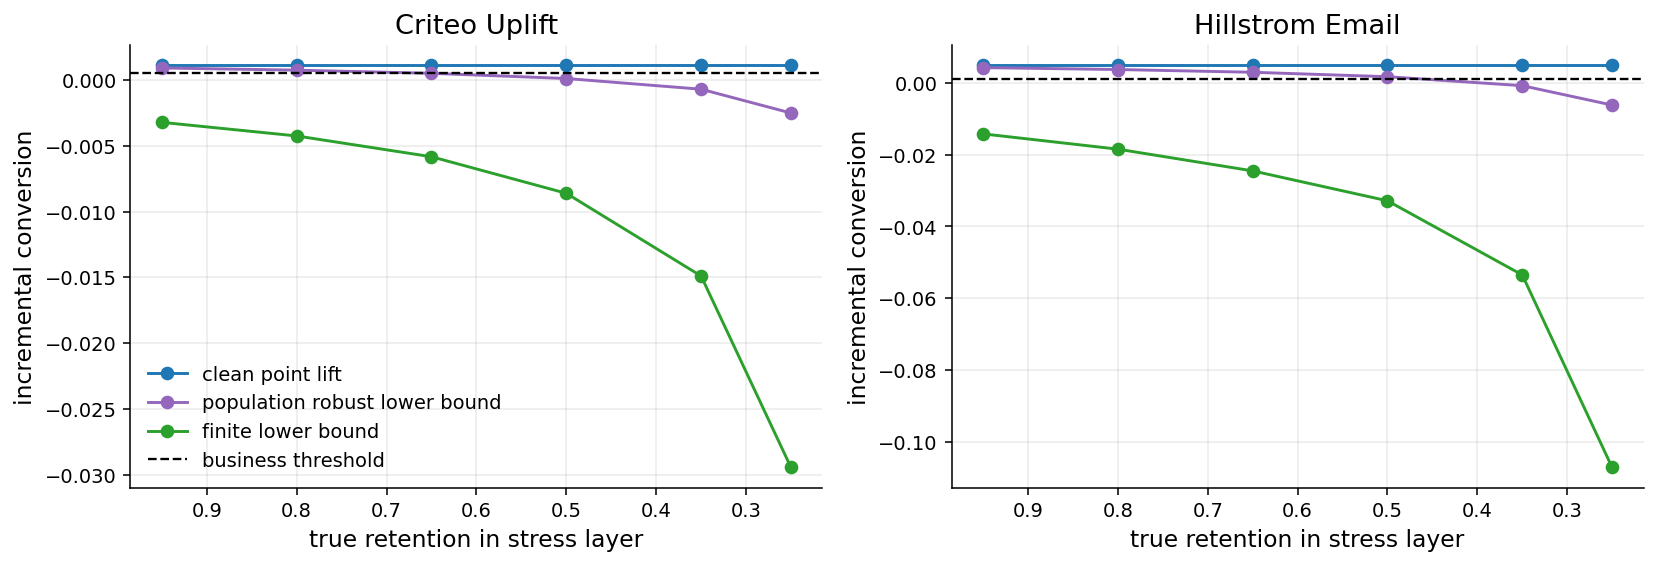

In [3]:
plot_frontier(frontier, paths.figure_dir / "privacy_frontier_main.png")


In [4]:
# Finite-sample coverage diagnostic for Section 5.2.
criteo_stats = frontier[frontier["dataset"].eq("Criteo Uplift")].iloc[0]
coverage = simulate_finite_sample_coverage(
    mu_treat=float(criteo_stats["mu_treat"]),
    mu_control=float(criteo_stats["mu_control"]),
    n_treat=int(criteo_stats["n_treat"]),
    n_control=int(criteo_stats["n_control"]),
    q_true=0.7,
    q_low=0.6,
    q_high=0.8,
    bound=1.0,
    alpha=0.05,
    reps=250,
    sigma_noise=2.0,
)
coverage_summary = pd.DataFrame([{
    "covered_share": coverage["covered"].mean(),
    "mean_width": coverage["width"].mean(),
    "p05_width": coverage["width"].quantile(0.05),
    "p95_width": coverage["width"].quantile(0.95),
}])
write_table(coverage, paths.table_dir / "finite_sample_coverage_reps.csv")
write_table(coverage_summary, paths.table_dir / "finite_sample_coverage_summary.csv")
coverage_summary


,covered_share,mean_width,p05_width,p95_width
0,1.0,0.011086,0.010903,0.011291
